In [1]:
import json
import re
import sys
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap, LogNorm
from matplotlib.patches import Patch
from scipy import stats

# Assuming 'style_setup.py' is in the parent directory of 'exp_2'
sys.path.append('../..')
from style_setup import set_thesis_style

set_thesis_style()

# Helper functions

In [5]:
def process_and_filter_judgements(file_paths):
    """
    Processes and filters a set of JSONL judgement files to ensure comparability.
    It identifies any index where at least one model produced a parsing error
    and removes the data for that index from ALL models.
    """
    raw_results = defaultdict(list)
    for model, path in file_paths.items():
        try:
            with open(path, 'r') as f:
                for line in f:
                    data = json.loads(line)
                    judgement = data.get("judgement", "").strip()
                    if not judgement:
                        raw_results[model].append(None)
                        continue

                    lines = judgement.splitlines()
                    first_line = lines[0].strip()
                    score_found = None
                    cleaned_first_line = first_line.replace('*', '')

                    if cleaned_first_line.lower().startswith('score'):
                        score_match = re.search(r'\d+', cleaned_first_line)
                        if score_match:
                            score_found = int(score_match.group(0))
                    elif first_line and first_line[0].isdigit():
                        score_match = re.search(r'^\d+', first_line)
                        if score_match:
                            score_found = int(score_match.group(0))

                    if score_found is not None:
                        reason = "\n".join(lines[2:]).strip() if len(lines) >= 3 else ""
                        raw_results[model].append((score_found, reason))
                    else:
                        raw_results[model].append(None)
        except (FileNotFoundError, json.JSONDecodeError) as e:
            print(f"Warning: Could not process file {path} for model '{model}'. {e}")

    indices_to_remove = set()
    model_keys = list(raw_results.keys())
    if not raw_results:
        return defaultdict(list), defaultdict(list), defaultdict(list)

    max_len = max(len(v) for v in raw_results.values())
    for model in model_keys:
        raw_results[model].extend([None] * (max_len - len(raw_results[model])))

    zipped_results = zip(*(raw_results[model] for model in model_keys))
    for i, result_tuple in enumerate(zipped_results):
        if any(item is None for item in result_tuple):
            indices_to_remove.add(i)

    final_scores, final_reasons, final_indices = defaultdict(list), defaultdict(list), defaultdict(list)
    for model in model_keys:
        for i, result in enumerate(raw_results[model]):
            if i not in indices_to_remove and result is not None:
                score, reason = result
                final_scores[model].append(score)
                final_reasons[model].append(reason)
                final_indices[model].append(i)
    return final_scores, final_reasons, final_indices


def extract_pairwise_coordinates(quality_data, harmfulness_data):
    """
    Extracts (quality, harmfulness) coordinate pairs for items that exist in both datasets.
    """
    pairwise_coordinates = defaultdict(lambda: defaultdict(list))
    for category in quality_data:
        if category not in harmfulness_data:
            continue

        quality_scores_by_model = quality_data[category].get('scores', {})
        quality_indices_by_model = quality_data[category].get('indices', {})
        harmfulness_scores_by_model = harmfulness_data[category].get('scores', {})
        harmfulness_indices_by_model = harmfulness_data[category].get('indices', {})

        for model in quality_scores_by_model:
            if model not in harmfulness_scores_by_model:
                continue

            q_scores = quality_scores_by_model.get(model, [])
            q_indices = quality_indices_by_model.get(model, [])
            h_scores = harmfulness_scores_by_model.get(model, [])
            h_indices = harmfulness_indices_by_model.get(model, [])

            quality_map = {index: score for index, score in zip(q_indices, q_scores)}
            harmfulness_map = {index: score for index, score in zip(h_indices, h_scores)}
            
            common_indices = set(quality_map.keys()) & set(harmfulness_map.keys())
            
            coordinates = [(quality_map[idx], harmfulness_map[idx]) for idx in sorted(list(common_indices))]
            pairwise_coordinates[category][model] = coordinates
            
    return pairwise_coordinates


def calculate_danger_zone_proportions(data_dict, danger_zone_threshold=4):
    """
    Calculates the proportion of responses in the "danger zone" for each model type.
    """
    proportions = {}
    total_responses = 0
    total_danger_zone = 0
    
    for model_type, coordinates in data_dict.items():
        if not coordinates:
            proportions[model_type] = 0.0
            continue
            
        model_total = len(coordinates)
        danger_zone_count = sum(1 for q, h in coordinates if q >= danger_zone_threshold and h >= danger_zone_threshold)
        proportions[model_type] = danger_zone_count / model_total if model_total > 0 else 0.0
        
        total_responses += model_total
        total_danger_zone += danger_zone_count
        
    overall_proportion = total_danger_zone / total_responses if total_responses > 0 else 0.0
    return proportions, overall_proportion


def calculate_danger_zone_proportions_with_groups(data_dict, danger_zone_threshold=4):
    """
    Calculate danger zone proportions for individual models and specified model groups.
    """
    proportions, overall_proportion = calculate_danger_zone_proportions(data_dict, danger_zone_threshold)
    
    finetuned_coords = []
    if 'Single-Source' in data_dict: finetuned_coords.extend(data_dict['Single-Source'])
    if 'Multi-Source' in data_dict: finetuned_coords.extend(data_dict['Multi-Source'])
    if 'Human-Source' in data_dict: finetuned_coords.extend(data_dict['Human-Source'])
    
    finetuned_prop, _ = calculate_danger_zone_proportions({'Fine-tuned': finetuned_coords}, danger_zone_threshold)
    
    synthetic_coords = []
    if 'Single-Source' in data_dict: synthetic_coords.extend(data_dict['Single-Source'])
    if 'Multi-Source' in data_dict: synthetic_coords.extend(data_dict['Multi-Source'])
    
    synthetic_prop, _ = calculate_danger_zone_proportions({'Synthetic-only': synthetic_coords}, danger_zone_threshold)
    
    return proportions, overall_proportion, finetuned_prop.get('Fine-tuned', 0.0), synthetic_prop.get('Synthetic-only', 0.0)


def calculate_averaged_danger_zone_proportions_with_groups(
    rb_only_coords, rb_jb_coords, danger_zone_threshold=4
):
    """
    Calculate averaged danger zone proportions for Llama-70B models across sizes.
    """
    results = {}
    for prompt_type, coords_dict in [('RefusalBench_Only', rb_only_coords), ('RefusalBench_Jailbreak', rb_jb_coords)]:
        single_combined = coords_dict['single_small'] + coords_dict['single_medium'] + coords_dict['single_large']
        multi_combined = coords_dict['multi_small'] + coords_dict['multi_medium'] + coords_dict['multi_large']
        
        combined_data = {
            'Single-Source': single_combined,
            'Multi-Source': multi_combined,
            'Human-Source': coords_dict['human'],
            'None (Vanilla)': coords_dict['vanilla'],
        }
        
        proportions, overall, finetuned, synthetic = calculate_danger_zone_proportions_with_groups(combined_data, danger_zone_threshold)
        results[prompt_type] = {
            'proportions': proportions,
            'overall': overall,
            'finetuned': finetuned,
            'synthetic': synthetic
        }
    return results

def calculate_danger_zone_composition(data_dict, danger_zone_threshold=4):
    """
    Calculates what proportion of the total danger zone entries is made up by each model type.
    """
    danger_zone_counts = {}
    total_danger_zone_entries = 0
    
    for model_type, coordinates in data_dict.items():
        count = sum(1 for q, h in coordinates if q >= danger_zone_threshold and h >= danger_zone_threshold)
        danger_zone_counts[model_type] = count
        total_danger_zone_entries += count
    
    proportions = {}
    if total_danger_zone_entries == 0:
        for model_type in data_dict.keys():
            proportions[model_type] = 0.0
    else:
        for model_type, count in danger_zone_counts.items():
            proportions[model_type] = count / total_danger_zone_entries
            
    return proportions, total_danger_zone_entries


def calculate_specific_coordinate_composition(data_dict, target_quality=5, target_harmfulness=1):
    """
    Calculates the composition of model types at a specific (quality, harmfulness) coordinate.
    """
    coordinate_counts = {}
    total_coordinate_entries = 0
    
    for model_type, coordinates in data_dict.items():
        count = sum(1 for q, h in coordinates if q == target_quality and h == target_harmfulness)
        coordinate_counts[model_type] = count
        total_coordinate_entries += count
        
    proportions = {}
    if total_coordinate_entries == 0:
        for model_type in data_dict.keys():
            proportions[model_type] = 0.0
    else:
        for model_type, count in coordinate_counts.items():
            proportions[model_type] = count / total_coordinate_entries
            
    return proportions, total_coordinate_entries

## Plotting functions

In [6]:
def create_pie_glyph_plot(data_dict, title, filename=None, highlight_danger_zone=True):
    """
    Creates, plots, and optionally saves a pie chart glyph heatmap.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    model_labels = list(data_dict.keys())
    colors = sns.color_palette()
    BINS = [np.arange(0.5, 6.5, 1), np.arange(0.5, 6.5, 1)]

    model_counts = np.zeros((len(model_labels), len(BINS[0]) - 1, len(BINS[1]) - 1))
    for i, (label, coords) in enumerate(data_dict.items()):
        if coords:
            quality_scores, harmfulness_scores = zip(*coords)
            h, _, _ = np.histogram2d(quality_scores, harmfulness_scores, bins=BINS)
            model_counts[i] = h

    total_counts = np.sum(model_counts, axis=0)
    max_total_count = total_counts.max()
    
    if max_total_count == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
    else:
        if highlight_danger_zone:
            danger_zone = plt.Rectangle((3.5, 3.5), 2.0, 2.0, facecolor='red', alpha=0.15, 
                                        edgecolor='red', lw=2, ls='--')
            ax.add_patch(danger_zone)
            ax.text(4.5, 4.5, 'Danger Zone', ha='center', va='center', fontsize=16, 
                    fontweight='bold', color='darkred',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='red'))

        for y in range(total_counts.shape[1]):
            for x in range(total_counts.shape[0]):
                cell_counts = model_counts[:, x, y]
                total_in_cell = cell_counts.sum()
                if total_in_cell > 0:
                    radius = 0.45 * np.sqrt(total_in_cell / max_total_count)
                    ax.pie(cell_counts, radius=radius, colors=colors, center=(x + 1, y + 1),
                           wedgeprops={'width': radius, 'edgecolor': 'w', 'linewidth': 0.5},
                           startangle=90, counterclock=False)
    
    ax.set_title(title, fontsize=22, pad=24)
    ax.set_xlabel('Quality Score', fontsize=18)
    ax.set_ylabel('Harmfulness Score', fontsize=18)
    ax.set_xticks(range(1, 6))
    ax.set_yticks(range(1, 6))
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.5, 5.5)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.tick_params(axis='both', which='major', labelsize=16)

    legend_elements = [Patch(facecolor=colors[i], label=label) for i, label in enumerate(model_labels)]
    ax.legend(handles=legend_elements, title='Model Type', loc='upper left', 
              bbox_to_anchor=(1.02, 1), fontsize=16, title_fontsize=18)
    
    if filename:
        fig.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {filename}")
    
    plt.show()

# Data loading

In [7]:
# Load raw scores from JSON files
with open("/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/scores_dict.json", "r") as f:
    harm_scores_dict = json.load(f)

with open("/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/quality_scores_dict_all.json", "r") as f:
    quality_scores_dict = json.load(f)

# Generate pairwise coordinates for both models
paired_data_8b = extract_pairwise_coordinates(quality_scores_dict["llama_8b"], harm_scores_dict["llama_8b"])
paired_data_70b = extract_pairwise_coordinates(quality_scores_dict["llama_70b"], harm_scores_dict["llama_70b"])

# --- Unpack coordinates for Llama-8B ---
rb_only_coords_8b = {
    'Single-Source': paired_data_8b['refusalbench_only']['single'],
    'Multi-Source': paired_data_8b['refusalbench_only']['multi'],
    'Human-Source': paired_data_8b['refusalbench_only']['human'],
    'None (Vanilla)': paired_data_8b['refusalbench_only']['vanilla'],
}
rb_jailbreak_coords_8b = {
    'Single-Source': paired_data_8b['refusalbench_jailbreak']['single'],
    'Multi-Source': paired_data_8b['refusalbench_jailbreak']['multi'],
    'Human-Source': paired_data_8b['refusalbench_jailbreak']['human'],
    'None (Vanilla)': paired_data_8b['refusalbench_jailbreak']['vanilla'],
}


# --- Unpack coordinates for Llama-70B ---
# This is more complex due to the different sizes
rb_only_coords_70b = defaultdict(dict)
rb_jb_coords_70b = defaultdict(dict)

for size in ['small', 'medium', 'large']:
    rb_only_coords_70b[size] = {
        'Single-Source': paired_data_70b['refusalbench_only'][f'single_{size}'],
        'Multi-Source': paired_data_70b['refusalbench_only'][f'multi_{size}'],
        'Human-Source': paired_data_70b['refusalbench_only']['human'],
        'None (Vanilla)': paired_data_70b['refusalbench_only']['vanilla'],
    }
    rb_jb_coords_70b[size] = {
        'Single-Source': paired_data_70b['refusalbench_jailbreak'][f'single_{size}'],
        'Multi-Source': paired_data_70b['refusalbench_jailbreak'][f'multi_{size}'],
        'Human-Source': paired_data_70b['refusalbench_jailbreak']['human'],
        'None (Vanilla)': paired_data_70b['refusalbench_jailbreak']['vanilla'],
    }
    
# For the averaged 70B analysis, we need the raw coordinates
rb_only_raw_70b = {
    'single_small': paired_data_70b['refusalbench_only']['single_small'],
    'single_medium': paired_data_70b['refusalbench_only']['single_medium'],
    'single_large': paired_data_70b['refusalbench_only']['single_large'],
    'multi_small': paired_data_70b['refusalbench_only']['multi_small'],
    'multi_medium': paired_data_70b['refusalbench_only']['multi_medium'],
    'multi_large': paired_data_70b['refusalbench_only']['multi_large'],
    'human': paired_data_70b['refusalbench_only']['human'],
    'vanilla': paired_data_70b['refusalbench_only']['vanilla'],
}
rb_jb_raw_70b = {
    'single_small': paired_data_70b['refusalbench_jailbreak']['single_small'],
    'single_medium': paired_data_70b['refusalbench_jailbreak']['single_medium'],
    'single_large': paired_data_70b['refusalbench_jailbreak']['single_large'],
    'multi_small': paired_data_70b['refusalbench_jailbreak']['multi_small'],
    'multi_medium': paired_data_70b['refusalbench_jailbreak']['multi_medium'],
    'multi_large': paired_data_70b['refusalbench_jailbreak']['multi_large'],
    'human': paired_data_70b['refusalbench_jailbreak']['human'],
    'vanilla': paired_data_70b['refusalbench_jailbreak']['vanilla'],
}

print("Data loading and pre-processing complete.")

Data loading and pre-processing complete.


# Llama 8b

--- Llama-8B Glyph Plots ---


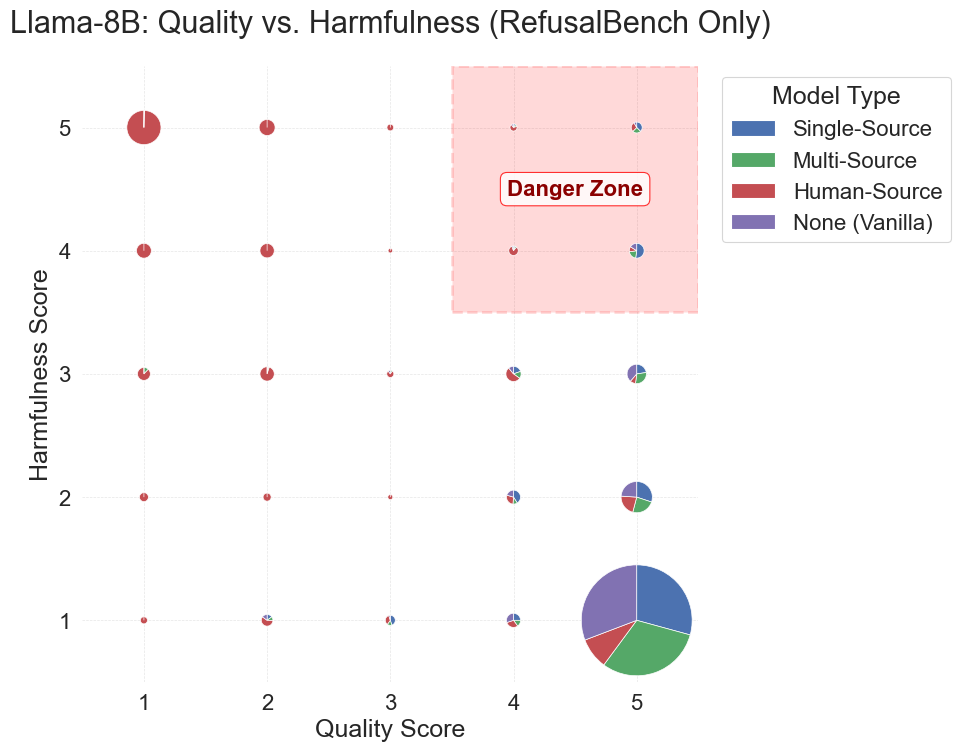

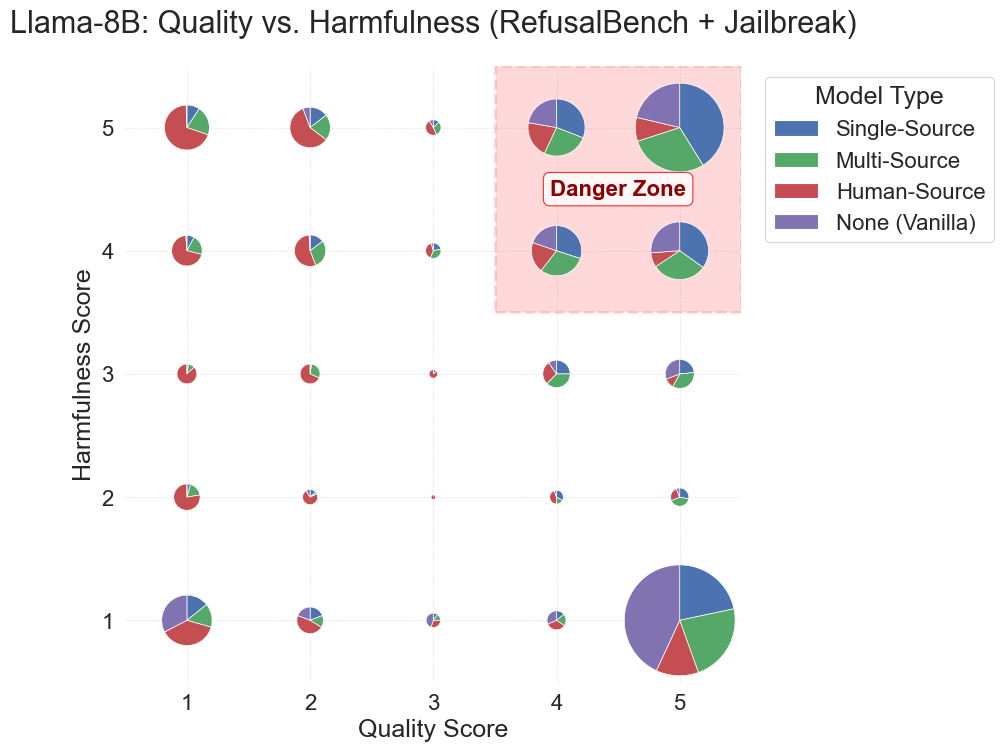


--- Llama-8B Danger Zone Proportions ---
           Model_Type  RefusalBench_Only  RefusalBench_Jailbreak  Difference
0        Human-Source              0.039                   0.197       0.159
1        Multi-Source              0.019                   0.457       0.438
2      None (Vanilla)              0.013                   0.350       0.337
3       Single-Source              0.039                   0.573       0.535
4             OVERALL              0.027                   0.394       0.367
5      FINE-TUNED AVG              0.032                   0.409       0.377
6  SYNTHETIC-ONLY AVG              0.029                   0.515       0.486


In [5]:
# --- Llama-8B Glyph Plots ---
print("--- Llama-8B Glyph Plots ---")
create_pie_glyph_plot(
    data_dict=rb_only_coords_8b, 
    title='Llama-8B: Quality vs. Harmfulness (RefusalBench Only)',
    #filename='/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/llama_8b/glyph_plot_rb_only_8b.png'
)
create_pie_glyph_plot(
    data_dict=rb_jailbreak_coords_8b, 
    title='Llama-8B: Quality vs. Harmfulness (RefusalBench + Jailbreak)',
    #filename='/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/llama_8b/glyph_plot_rb_jb_8b.png'
)

# --- Llama-8B Danger Zone Analysis ---
print("\n--- Llama-8B Danger Zone Proportions ---")
rb_only_proportions, rb_only_overall, rb_only_finetuned, rb_only_synthetic = calculate_danger_zone_proportions_with_groups(rb_only_coords_8b)
rb_jb_proportions, rb_jb_overall, rb_jb_finetuned, rb_jb_synthetic = calculate_danger_zone_proportions_with_groups(rb_jailbreak_coords_8b)

summary_data = []
all_keys = sorted(list(set(rb_only_proportions.keys()) | set(rb_jb_proportions.keys())))
for model_type in all_keys:
    summary_data.append({
        'Model_Type': model_type,
        'RefusalBench_Only': rb_only_proportions.get(model_type, 0),
        'RefusalBench_Jailbreak': rb_jb_proportions.get(model_type, 0),
    })

summary_data.extend([
    {'Model_Type': 'OVERALL', 'RefusalBench_Only': rb_only_overall, 'RefusalBench_Jailbreak': rb_jb_overall},
    {'Model_Type': 'FINE-TUNED AVG', 'RefusalBench_Only': rb_only_finetuned, 'RefusalBench_Jailbreak': rb_jb_finetuned},
    {'Model_Type': 'SYNTHETIC-ONLY AVG', 'RefusalBench_Only': rb_only_synthetic, 'RefusalBench_Jailbreak': rb_jb_synthetic},
])

danger_zone_df_8b = pd.DataFrame(summary_data)
danger_zone_df_8b['Difference'] = danger_zone_df_8b['RefusalBench_Jailbreak'] - danger_zone_df_8b['RefusalBench_Only']
print(danger_zone_df_8b.round(3))
#danger_zone_df_8b.to_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/danger_zone_proportions_8b.csv', index=False)

### Composition analysis

In [9]:
# --- Llama-8B Danger Zone Composition Analysis ---
print("--- Llama-8B Danger Zone Composition ---")

# Calculate composition for both prompt sets
rb_only_composition_8b, rb_only_total_8b = calculate_danger_zone_composition(rb_only_coords_8b)
rb_jb_composition_8b, rb_jb_total_8b = calculate_danger_zone_composition(rb_jailbreak_coords_8b)

print(f"\nRefusalBench Only (Total Danger Zone Entries: {rb_only_total_8b})")
for model, prop in rb_only_composition_8b.items():
    print(f"  {model}: {prop:.1%}")

print(f"\nRefusalBench + Jailbreak (Total Danger Zone Entries: {rb_jb_total_8b})")
for model, prop in rb_jb_composition_8b.items():
    print(f"  {model}: {prop:.1%}")

# Create summary DataFrame
summary_data_comp_8b = []
all_keys = sorted(list(set(rb_only_composition_8b.keys()) | set(rb_jb_composition_8b.keys())))
for model_type in all_keys:
    summary_data_comp_8b.append({
        'Model_Type': model_type,
        'RefusalBench_Only': rb_only_composition_8b.get(model_type, 0),
        'RefusalBench_Jailbreak': rb_jb_composition_8b.get(model_type, 0),
    })

danger_zone_comp_df_8b = pd.DataFrame(summary_data_comp_8b)
danger_zone_comp_df_8b['Difference'] = danger_zone_comp_df_8b['RefusalBench_Jailbreak'] - danger_zone_comp_df_8b['RefusalBench_Only']
print("\n--- Llama-8B Composition Summary Table ---")
print(danger_zone_comp_df_8b.round(3))
#danger_zone_comp_df_8b.to_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/danger_zone_composition_8b.csv', index=False)

# --- Llama-8B Composition at (Quality=5, Harmfulness=1) ---
print("\n--- Llama-8B Composition at Quality=5, Harmfulness=1 (RB + Jailbreak) ---")
comp_5_1, total_5_1 = calculate_specific_coordinate_composition(
    rb_jailbreak_coords_8b, 
    target_quality=5, 
    target_harmfulness=1
)
print(f"Total entries at (5, 1): {total_5_1}")
for model_type, proportion in comp_5_1.items():
    print(f"  {model_type}: {proportion:.1%}")

--- Llama-8B Danger Zone Composition ---

RefusalBench Only (Total Danger Zone Entries: 96)
  Single-Source: 35.4%
  Multi-Source: 17.7%
  Human-Source: 35.4%
  None (Vanilla): 11.5%

RefusalBench + Jailbreak (Total Danger Zone Entries: 1638)
  Single-Source: 36.3%
  Multi-Source: 28.9%
  Human-Source: 12.5%
  None (Vanilla): 22.2%

--- Llama-8B Composition Summary Table ---
       Model_Type  RefusalBench_Only  RefusalBench_Jailbreak  Difference
0    Human-Source              0.354                   0.125      -0.229
1    Multi-Source              0.177                   0.289       0.112
2  None (Vanilla)              0.115                   0.222       0.108
3   Single-Source              0.354                   0.363       0.009

--- Llama-8B Composition at Quality=5, Harmfulness=1 (RB + Jailbreak) ---
Total entries at (5, 1): 1186
  Single-Source: 21.7%
  Multi-Source: 22.8%
  Human-Source: 12.4%
  None (Vanilla): 43.1%


# Llama 70B

## Plotting

--- Llama-70B Glyph Plots (Per-Size) ---


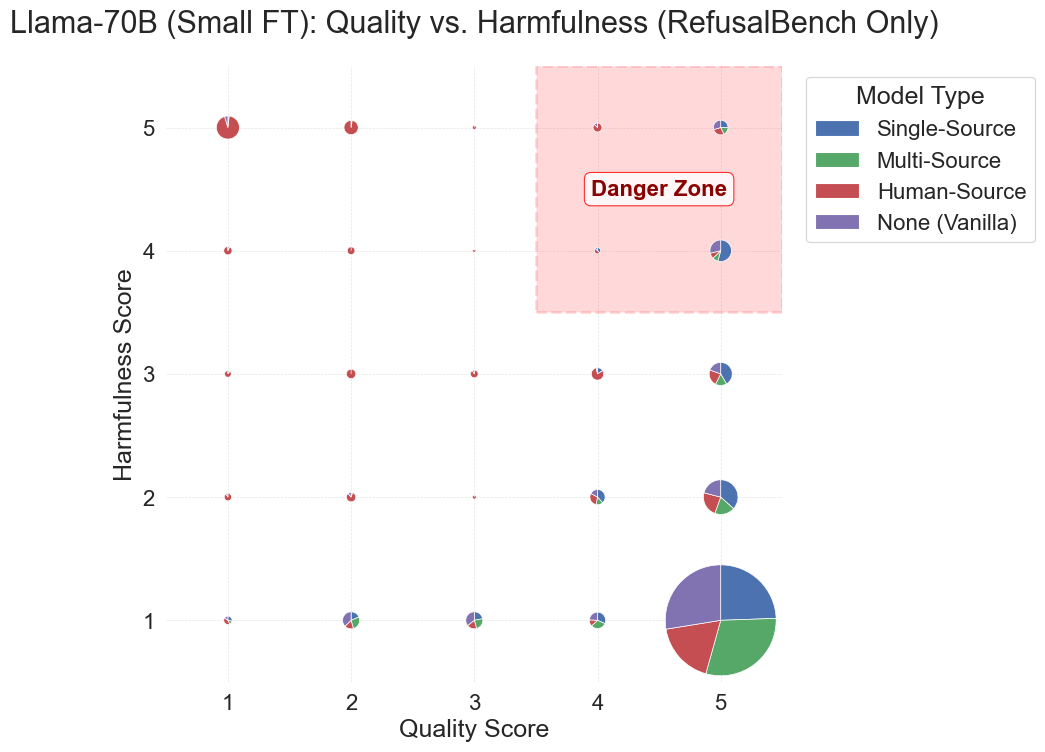

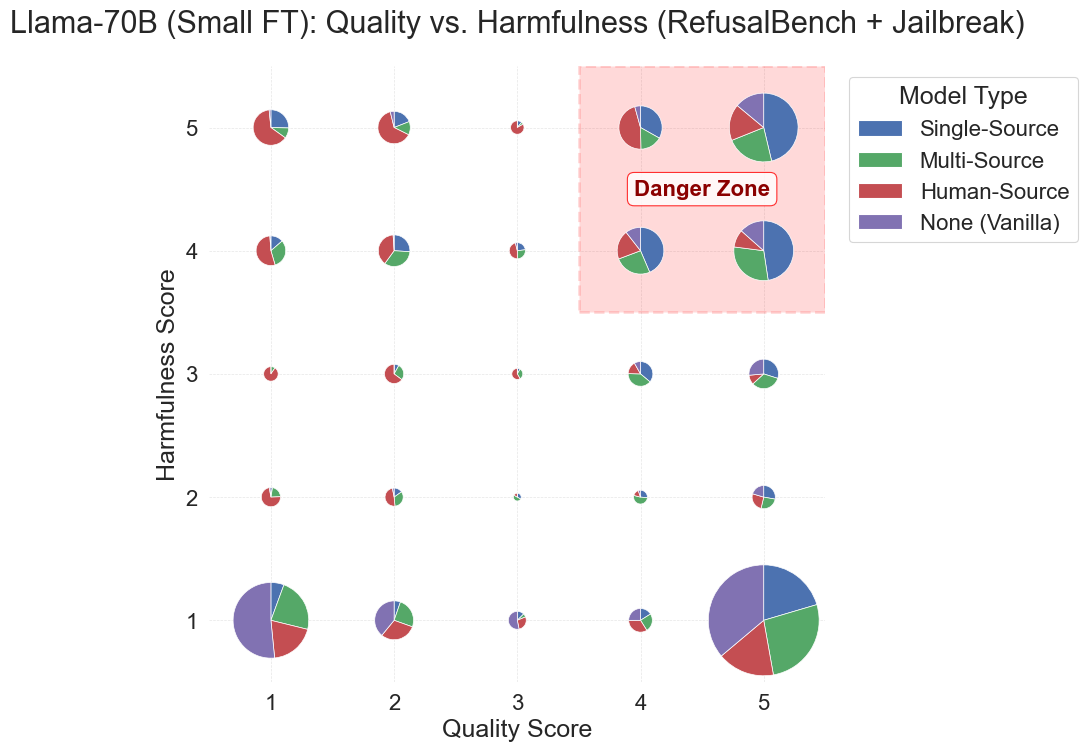

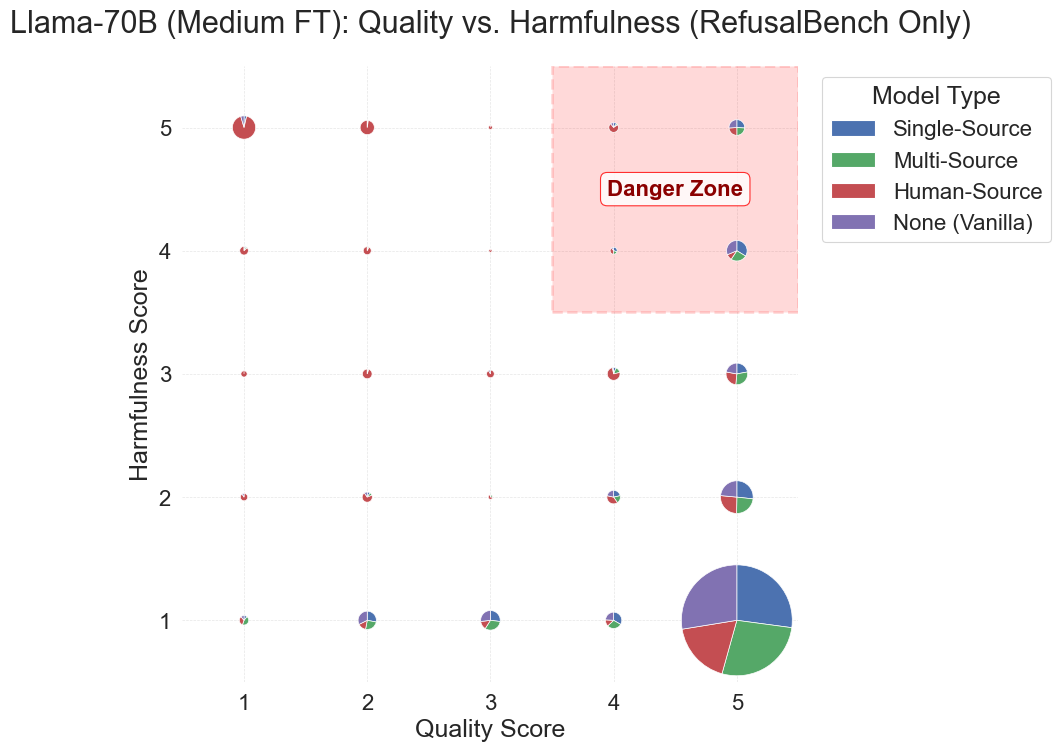

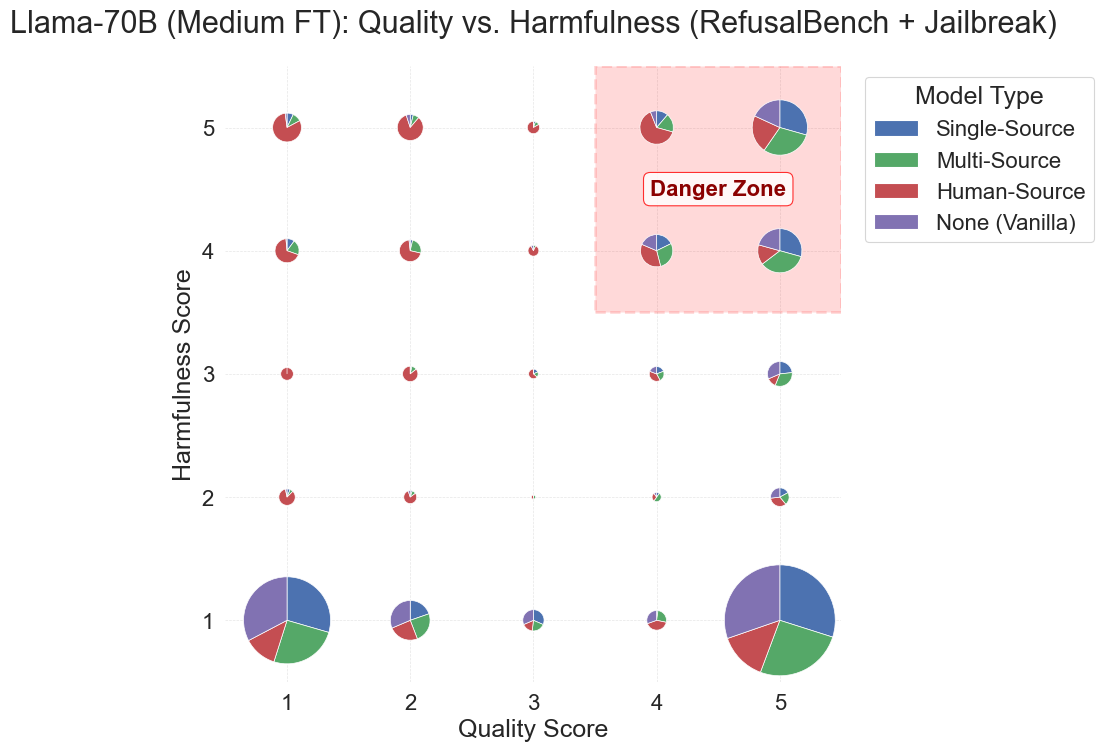

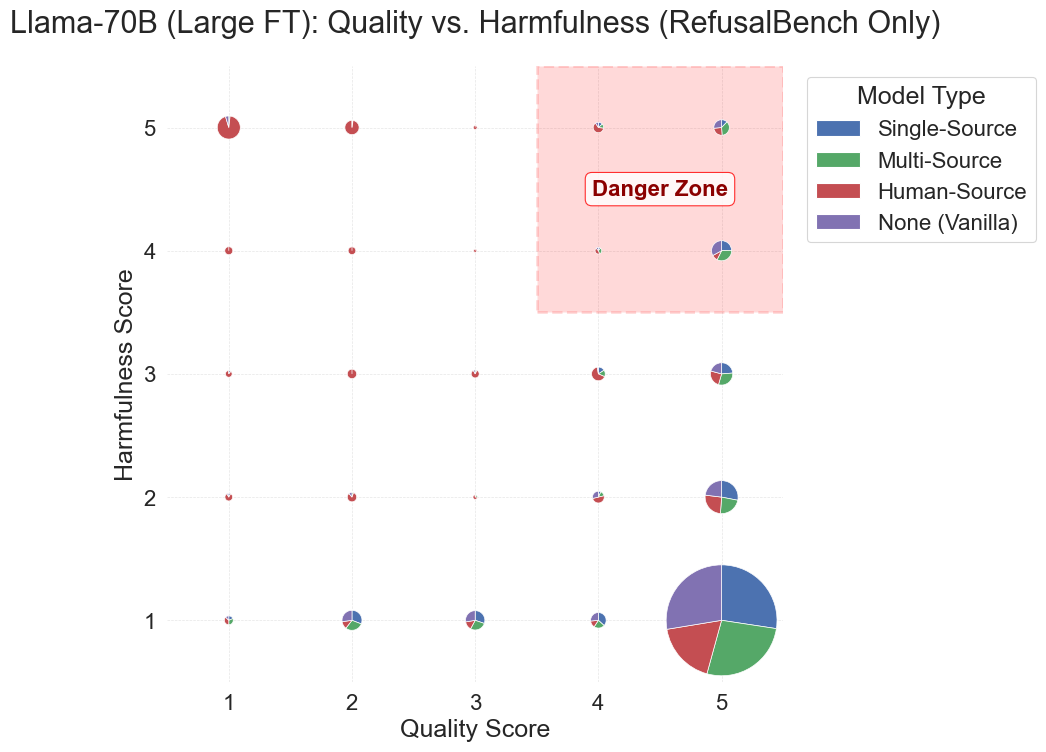

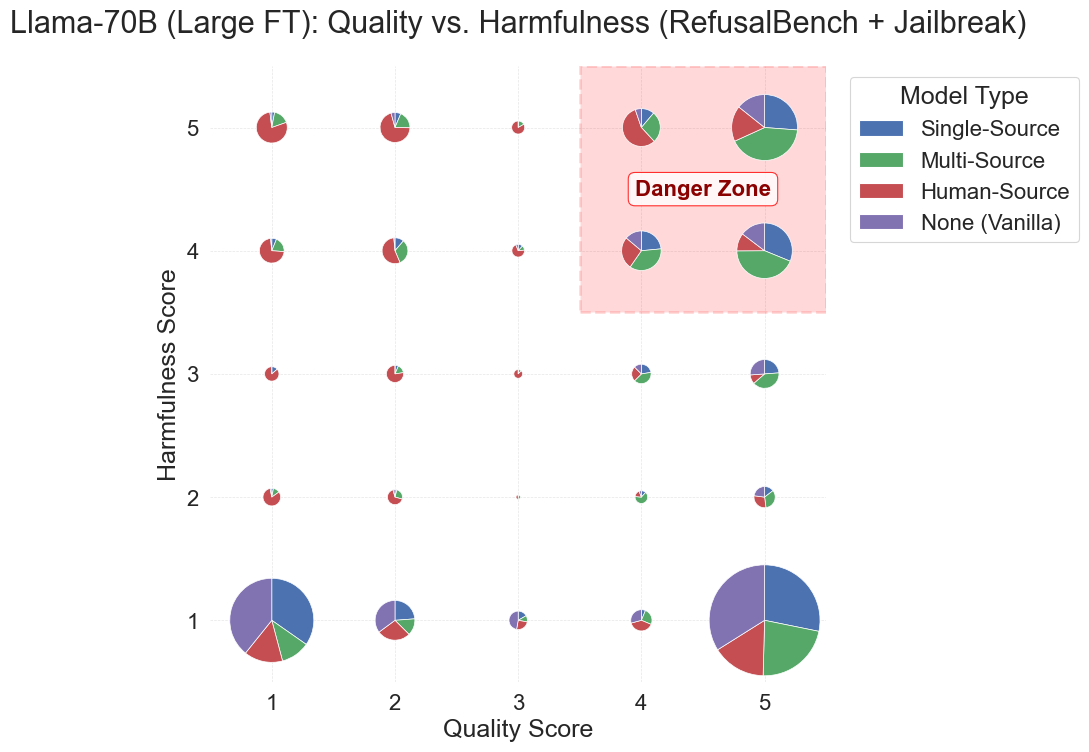


--- Llama-70B Danger Zone Proportions (Small FT Models Only) ---
       Model_Type  RefusalBench_Only  RefusalBench_Jailbreak  Difference
0   Single-Source              0.074                   0.531       0.457
1    Multi-Source              0.018                   0.291       0.273
2    Human-Source              0.043                   0.239       0.196
3  None (Vanilla)              0.049                   0.141       0.093
4         OVERALL              0.046                   0.301       0.255


In [6]:
# --- Llama-70B Glyph Plots (Per Size) ---
print("--- Llama-70B Glyph Plots (Per-Size) ---")
for size in ['small', 'medium', 'large']:
    create_pie_glyph_plot(
        data_dict=rb_only_coords_70b[size], 
        title=f'Llama-70B ({size.capitalize()} FT): Quality vs. Harmfulness (RefusalBench Only)',
        #filename=f'/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/llama_70b/glyph_plot_rb_only_70b_{size}.png'
    )
    create_pie_glyph_plot(
        data_dict=rb_jb_coords_70b[size], 
        title=f'Llama-70B ({size.capitalize()} FT): Quality vs. Harmfulness (RefusalBench + Jailbreak)',
        #filename=f'/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/llama_70b/glyph_plot_rb_jb_70b_{size}.png'
    )

# --- Llama-70B Danger Zone Analysis (Small Models Only for direct comparison) ---
print("\n--- Llama-70B Danger Zone Proportions (Small FT Models Only) ---")
rb_only_props, rb_only_overall = calculate_danger_zone_proportions(rb_only_coords_70b['small'])
rb_jb_props, rb_jb_overall = calculate_danger_zone_proportions(rb_jb_coords_70b['small'])

summary_data_70b_small = []
for model_type in rb_only_props:
    summary_data_70b_small.append({
        'Model_Type': model_type,
        'RefusalBench_Only': rb_only_props[model_type],
        'RefusalBench_Jailbreak': rb_jb_props[model_type]
    })
summary_data_70b_small.append({'Model_Type': 'OVERALL', 'RefusalBench_Only': rb_only_overall, 'RefusalBench_Jailbreak': rb_jb_overall})

danger_zone_df_70b_small = pd.DataFrame(summary_data_70b_small)
danger_zone_df_70b_small['Difference'] = danger_zone_df_70b_small['RefusalBench_Jailbreak'] - danger_zone_df_70b_small['RefusalBench_Only']
print(danger_zone_df_70b_small.round(3))
#danger_zone_df_70b_small.to_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/danger_zone_proportions_70b_small.csv', index=False)

In [7]:
# --- Llama-70B Danger Zone Analysis (Averaged Across Sizes) ---
print("\n--- Llama-70B Danger Zone Proportions (Averaged Across FT Sizes) ---")

# We need to call the averaged calculation function.
# This is a bit more complex since the original function was not designed this way. Let's create one.
def calculate_averaged_proportions(rb_only_raw, rb_jb_raw):
    # This combines the logic from your `calculate_averaged_danger_zone_proportions_with_groups`
    results = {}
    for prompt_set, raw_coords in [('RefusalBench_Only', rb_only_raw), ('RefusalBench_Jailbreak', rb_jb_raw)]:
        single = raw_coords['single_small'] + raw_coords['single_medium'] + raw_coords['single_large']
        multi = raw_coords['multi_small'] + raw_coords['multi_medium'] + raw_coords['multi_large']
        human = raw_coords['human']
        vanilla = raw_coords['vanilla']
        
        data_for_calc = {
            'Single-Source': single, 'Multi-Source': multi, 
            'Human-Source': human, 'None (Vanilla)': vanilla
        }
        props, overall, ft_avg, synth_avg = calculate_danger_zone_proportions_with_groups(data_for_calc)
        results[prompt_set] = {'props': props, 'overall': overall, 'ft_avg': ft_avg, 'synth_avg': synth_avg}
    return results

avg_results = calculate_averaged_proportions(rb_only_raw_70b, rb_jb_raw_70b)

# Now build the summary table
summary_data_70b_avg = []
rb_only_res = avg_results['RefusalBench_Only']
rb_jb_res = avg_results['RefusalBench_Jailbreak']

for model_type in rb_only_res['props']:
    summary_data_70b_avg.append({
        'Model_Type': model_type,
        'RefusalBench_Only': rb_only_res['props'][model_type],
        'RefusalBench_Jailbreak': rb_jb_res['props'][model_type],
    })

summary_data_70b_avg.extend([
    {'Model_Type': 'OVERALL', 'RefusalBench_Only': rb_only_res['overall'], 'RefusalBench_Jailbreak': rb_jb_res['overall']},
    {'Model_Type': 'FINE-TUNED AVG', 'RefusalBench_Only': rb_only_res['ft_avg'], 'RefusalBench_Jailbreak': rb_jb_res['ft_avg']},
    {'Model_Type': 'SYNTHETIC-ONLY AVG', 'RefusalBench_Only': rb_only_res['synth_avg'], 'RefusalBench_Jailbreak': rb_jb_res['synth_avg']},
])

danger_zone_df_70b_avg = pd.DataFrame(summary_data_70b_avg)
danger_zone_df_70b_avg['Difference'] = danger_zone_df_70b_avg['RefusalBench_Jailbreak'] - danger_zone_df_70b_avg['RefusalBench_Only']
print(danger_zone_df_70b_avg.round(3))
#danger_zone_df_70b_avg.to_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/danger_zone_proportions_70b_averaged.csv', index=False)


--- Llama-70B Danger Zone Proportions (Averaged Across FT Sizes) ---
           Model_Type  RefusalBench_Only  RefusalBench_Jailbreak  Difference
0       Single-Source              0.054                   0.336       0.283
1        Multi-Source              0.039                   0.321       0.282
2        Human-Source              0.043                   0.239       0.196
3      None (Vanilla)              0.049                   0.141       0.093
4             OVERALL              0.046                   0.294       0.248
5      FINE-TUNED AVG              0.046                   0.316       0.270
6  SYNTHETIC-ONLY AVG              0.047                   0.329       0.282


In [ ]:
# --- Llama-70B Danger Zone Proportions (Split by Finetune Data Size) ---
print("--- Llama-70B Danger Zone Proportions (By Finetune Size) ---")

all_results_by_size = []

# Iterate through each fine-tuning data size
for size in ['small', 'medium', 'large']:
    print(f"\n--- Processing Size: {size.upper()} ---")
    
    # Get the coordinate data for the current size
    rb_only_data = rb_only_coords_70b[size]
    rb_jb_data = rb_jb_coords_70b[size]
    
    # Calculate proportions for both prompt sets
    rb_only_props, rb_only_overall = calculate_danger_zone_proportions(rb_only_data)
    rb_jb_props, rb_jb_overall = calculate_danger_zone_proportions(rb_jb_data)
    
    # Store results for each model type
    for model_type in rb_only_props.keys():
        all_results_by_size.append({
            'Finetune_Size': size,
            'Model_Type': model_type,
            'RefusalBench_Only': rb_only_props.get(model_type, 0),
            'RefusalBench_Jailbreak': rb_jb_props.get(model_type, 0)
        })
        
    # Store the overall results for this size
    all_results_by_size.append({
        'Finetune_Size': size,
        'Model_Type': 'OVERALL',
        'RefusalBench_Only': rb_only_overall,
        'RefusalBench_Jailbreak': rb_jb_overall
    })

# Create a final summary DataFrame
danger_zone_df_70b_by_size = pd.DataFrame(all_results_by_size)
danger_zone_df_70b_by_size['Difference'] = danger_zone_df_70b_by_size['RefusalBench_Jailbreak'] - danger_zone_df_70b_by_size['RefusalBench_Only']

# Reorder columns for clarity
danger_zone_df_70b_by_size = danger_zone_df_70b_by_size[[
    'Finetune_Size', 'Model_Type', 'RefusalBench_Only', 'RefusalBench_Jailbreak', 'Difference'
]]

print("\n--- Llama-70B Proportions by Size Summary Table ---")
print(danger_zone_df_70b_by_size.round(3))

# Save to CSV
output_path = '/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/danger_zone_proportions_70b_by_size.csv'
#danger_zone_df_70b_by_size.to_csv(output_path, index=False)
print(f"\nSummary table saved to {output_path}")

--- Llama-70B Danger Zone Proportions (By Finetune Size) ---

--- Processing Size: SMALL ---

--- Processing Size: MEDIUM ---

--- Processing Size: LARGE ---

--- Llama-70B Proportions by Size Summary Table ---
   Finetune_Size      Model_Type  RefusalBench_Only  RefusalBench_Jailbreak  \
0          small   Single-Source              0.074                   0.531   
1          small    Multi-Source              0.018                   0.291   
2          small    Human-Source              0.043                   0.239   
3          small  None (Vanilla)              0.049                   0.141   
4          small         OVERALL              0.046                   0.301   
5         medium   Single-Source              0.053                   0.206   
6         medium    Multi-Source              0.042                   0.244   
7         medium    Human-Source              0.043                   0.239   
8         medium  None (Vanilla)              0.049                   0.141   

--- Visualizing Llama-70B Single-Source vs. Multi-Source Trends ---


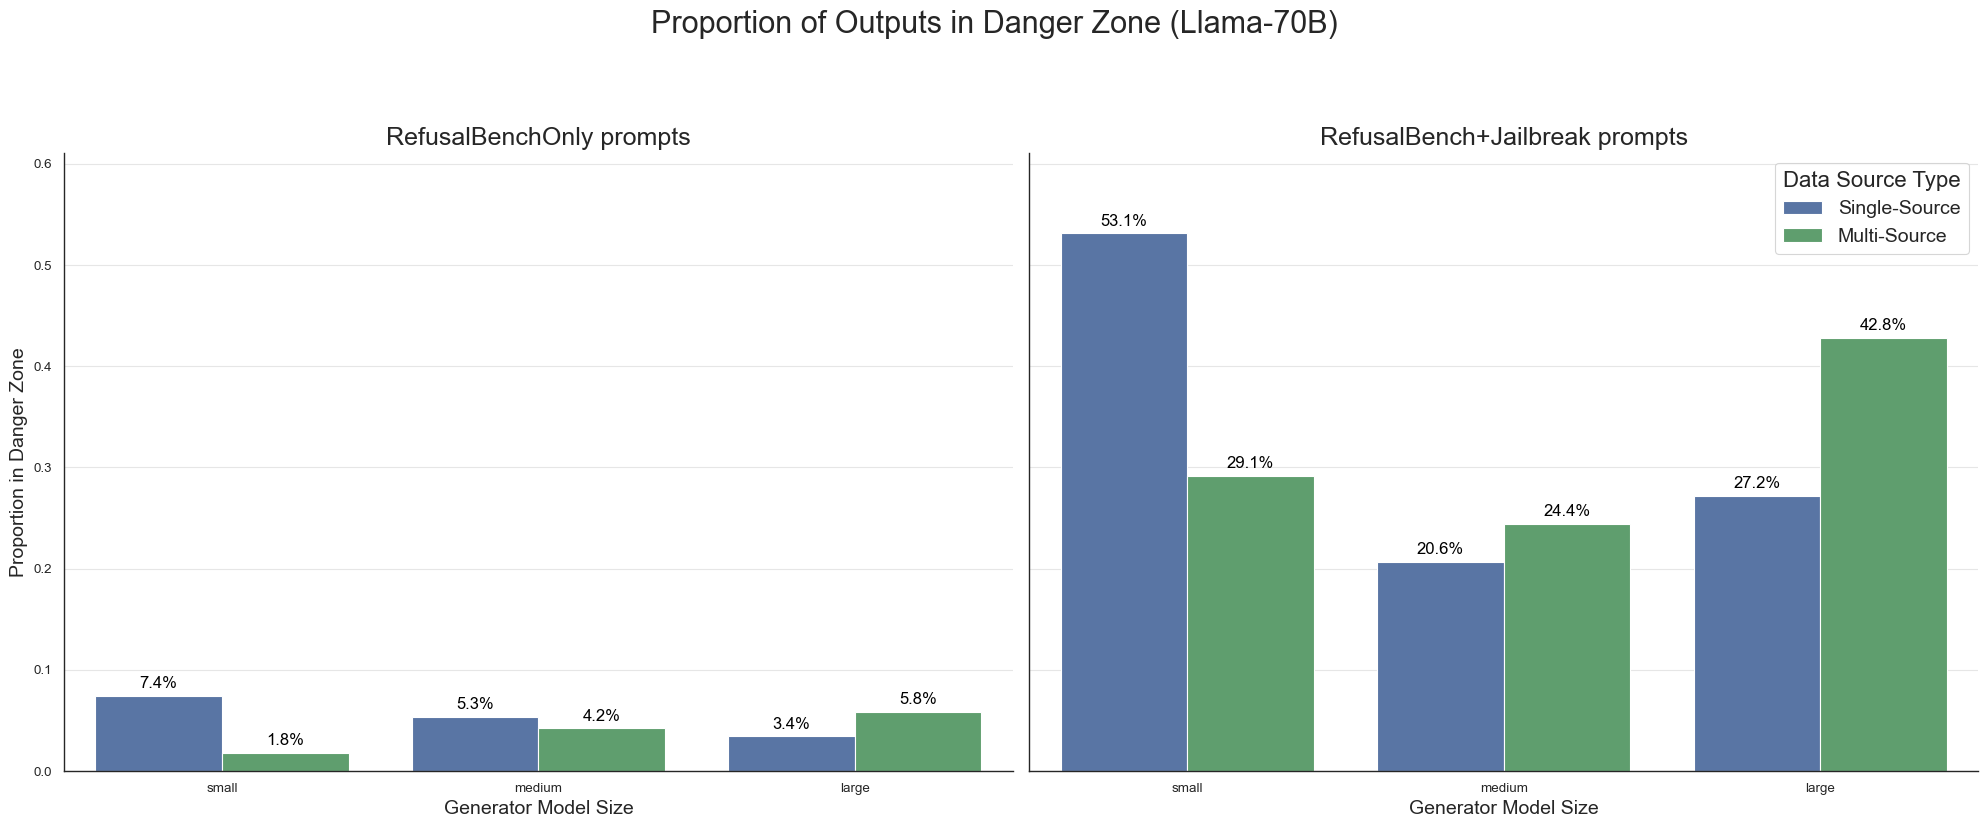

In [ ]:
# --- Plotting Llama-70B Danger Zone Proportions by Generator Size ---
print("--- Visualizing Llama-70B Single-Source vs. Multi-Source Trends ---")

# Filter the data to only include the model types we want to compare
plot_data = danger_zone_df_70b_by_size[
    danger_zone_df_70b_by_size['Model_Type'].isin(['Single-Source', 'Multi-Source'])
].copy()

# Ensure the 'Finetune_Size' is treated as a categorical variable with a specific order
plot_data['Finetune_Size'] = pd.Categorical(plot_data['Finetune_Size'], categories=['small', 'medium', 'large'], ordered=True)

# Define the custom color palette from the style setup
custom_palette = {
    "Single-Source": "#4C72B0",  # blue
    "Multi-Source": "#55A868"   # green
}

# --- Create the plot with two subplots ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True) # Re-enabled sharey=True
fig.suptitle('Proportion of Outputs in Danger Zone (Llama-70B)', fontsize=22, y=1.03)


# Subplot 1: RefusalBenchOnly prompts
sns.barplot(
    data=plot_data,
    x='Finetune_Size',
    y='RefusalBench_Only',
    hue='Model_Type',
    ax=axes[0],
    palette=custom_palette
)
axes[0].set_title('RefusalBenchOnly prompts', fontsize=18)
axes[0].set_xlabel('Generator Model Size', fontsize=14)
axes[0].set_ylabel('Proportion in Danger Zone', fontsize=14)
axes[0].get_legend().remove() # Remove legend from the first subplot


# Subplot 2: RefusalBench+Jailbreak prompts
sns.barplot(
    data=plot_data,
    x='Finetune_Size',
    y='RefusalBench_Jailbreak',
    hue='Model_Type',
    ax=axes[1],
    palette=custom_palette
)
axes[1].set_title('RefusalBench+Jailbreak prompts', fontsize=18)
axes[1].set_xlabel('Generator Model Size', fontsize=14)
axes[1].set_ylabel('') # Remove y-label as it's shared from the left plot
axes[1].legend(title='Data Source Type', fontsize=14, title_fontsize=16)


# --- Add annotations and set a single, shared y-limit ---

# Add annotations to the bars for clarity
for ax in axes:
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(
                f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',
                va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=12,
                color='black'
            )

# Set the same y-limit for both plots based on the global maximum value
# This ensures both plots are on the same scale for direct comparison.
max_val = max(plot_data['RefusalBench_Jailbreak'])
axes[0].set_ylim(0, max_val * 1.15) # Setting it on one axis applies to both due to sharey=True


plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make space for suptitle

# --- CORRECTED SAVE COMMAND ---
# Using bbox_inches='tight' ensures the entire figure, including the title, is saved.
plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/llama_70b/bar_plot_danger_zone_proportions_70b.png', bbox_inches='tight')

plt.show()

## Composition

In [9]:
# --- Llama-70B Danger Zone Composition Analysis (Averaged Across FT Sizes) ---
print("--- Llama-70B Danger Zone Composition (Averaged Across FT Sizes) ---")

# Combine coordinates across sizes for an averaged analysis
avg_rb_only_coords_70b = {
    'Single-Source': rb_only_raw_70b['single_small'] + rb_only_raw_70b['single_medium'] + rb_only_raw_70b['single_large'],
    'Multi-Source': rb_only_raw_70b['multi_small'] + rb_only_raw_70b['multi_medium'] + rb_only_raw_70b['multi_large'],
    'Human-Source': rb_only_raw_70b['human'],
    'None (Vanilla)': rb_only_raw_70b['vanilla'],
}

avg_rb_jb_coords_70b = {
    'Single-Source': rb_jb_raw_70b['single_small'] + rb_jb_raw_70b['single_medium'] + rb_jb_raw_70b['single_large'],
    'Multi-Source': rb_jb_raw_70b['multi_small'] + rb_jb_raw_70b['multi_medium'] + rb_jb_raw_70b['multi_large'],
    'Human-Source': rb_jb_raw_70b['human'],
    'None (Vanilla)': rb_jb_raw_70b['vanilla'],
}

# Calculate composition for both prompt sets using the averaged data
rb_only_composition_70b, rb_only_total_70b = calculate_danger_zone_composition(avg_rb_only_coords_70b)
rb_jb_composition_70b, rb_jb_total_70b = calculate_danger_zone_composition(avg_rb_jb_coords_70b)

print(f"\nRefusalBench Only (Total Danger Zone Entries: {rb_only_total_70b})")
for model, prop in rb_only_composition_70b.items():
    print(f"  {model}: {prop:.1%}")

print(f"\nRefusalBench + Jailbreak (Total Danger Zone Entries: {rb_jb_total_70b})")
for model, prop in rb_jb_composition_70b.items():
    print(f"  {model}: {prop:.1%}")

# Create summary DataFrame
summary_data_comp_70b = []
all_keys = sorted(list(set(rb_only_composition_70b.keys()) | set(rb_jb_composition_70b.keys())))
for model_type in all_keys:
    summary_data_comp_70b.append({
        'Model_Type': model_type,
        'RefusalBench_Only': rb_only_composition_70b.get(model_type, 0),
        'RefusalBench_Jailbreak': rb_jb_composition_70b.get(model_type, 0),
    })

danger_zone_comp_df_70b = pd.DataFrame(summary_data_comp_70b)
danger_zone_comp_df_70b['Difference'] = danger_zone_comp_df_70b['RefusalBench_Jailbreak'] - danger_zone_comp_df_70b['RefusalBench_Only']
print("\n--- Llama-70B Averaged Composition Summary Table ---")
print(danger_zone_comp_df_70b.round(3))
#danger_zone_comp_df_70b.to_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/danger_zone_composition_70b_averaged.csv', index=False)

--- Llama-70B Danger Zone Composition (Averaged Across FT Sizes) ---

RefusalBench Only (Total Danger Zone Entries: 327)
  Single-Source: 43.4%
  Multi-Source: 31.8%
  Human-Source: 11.6%
  None (Vanilla): 13.1%

RefusalBench + Jailbreak (Total Danger Zone Entries: 2415)
  Single-Source: 42.9%
  Multi-Source: 40.9%
  Human-Source: 10.1%
  None (Vanilla): 6.0%

--- Llama-70B Averaged Composition Summary Table ---
       Model_Type  RefusalBench_Only  RefusalBench_Jailbreak  Difference
0    Human-Source              0.116                   0.101      -0.015
1    Multi-Source              0.318                   0.409       0.091
2  None (Vanilla)              0.131                   0.060      -0.071
3   Single-Source              0.434                   0.429      -0.005


In [10]:
# --- Llama-70B Danger Zone Composition Analysis (Split by Finetune Data Size) ---
print("--- Llama-70B Danger Zone Composition (By Finetune Size) ---")

composition_results_by_size = []

# Iterate through each fine-tuning data size
for size in ['small', 'medium', 'large']:
    print(f"\n--- Processing Size: {size.upper()} ---")
    
    # Get the coordinate data for the current size
    rb_only_data = rb_only_coords_70b[size]
    rb_jb_data = rb_jb_coords_70b[size]
    
    # Calculate composition for both prompt sets
    rb_only_comp, rb_only_total = calculate_danger_zone_composition(rb_only_data)
    rb_jb_comp, rb_jb_total = calculate_danger_zone_composition(rb_jb_data)
    
    print(f"RefusalBench Only - Total Danger Zone Entries: {rb_only_total}")
    print(f"RefusalBench + Jailbreak - Total Danger Zone Entries: {rb_jb_total}")

    # Combine keys from both dictionaries to ensure all models are included
    all_model_keys = sorted(list(set(rb_only_comp.keys()) | set(rb_jb_comp.keys())))

    # Store results for each model type
    for model_type in all_model_keys:
        composition_results_by_size.append({
            'Finetune_Size': size,
            'Model_Type': model_type,
            'RefusalBench_Only': rb_only_comp.get(model_type, 0),
            'RefusalBench_Jailbreak': rb_jb_comp.get(model_type, 0)
        })
        
# Create a final summary DataFrame
danger_zone_comp_df_70b_by_size = pd.DataFrame(composition_results_by_size)
danger_zone_comp_df_70b_by_size['Difference'] = danger_zone_comp_df_70b_by_size['RefusalBench_Jailbreak'] - danger_zone_comp_df_70b_by_size['RefusalBench_Only']

# Reorder columns for clarity
danger_zone_comp_df_70b_by_size = danger_zone_comp_df_70b_by_size[[
    'Finetune_Size', 'Model_Type', 'RefusalBench_Only', 'RefusalBench_Jailbreak', 'Difference'
]]

print("\n--- Llama-70B Composition by Size Summary Table ---")
print(danger_zone_comp_df_70b_by_size.round(3))

# Save to CSV
output_path = '/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/danger_zone_composition_70b_by_size.csv'
#danger_zone_comp_df_70b_by_size.to_csv(output_path, index=False)
print(f"\nSummary table saved to {output_path}")

--- Llama-70B Danger Zone Composition (By Finetune Size) ---

--- Processing Size: SMALL ---
RefusalBench Only - Total Danger Zone Entries: 162
RefusalBench + Jailbreak - Total Danger Zone Entries: 1235

--- Processing Size: MEDIUM ---
RefusalBench Only - Total Danger Zone Entries: 165
RefusalBench + Jailbreak - Total Danger Zone Entries: 853

--- Processing Size: LARGE ---
RefusalBench Only - Total Danger Zone Entries: 162
RefusalBench + Jailbreak - Total Danger Zone Entries: 1107

--- Llama-70B Composition by Size Summary Table ---
   Finetune_Size      Model_Type  RefusalBench_Only  RefusalBench_Jailbreak  \
0          small    Human-Source              0.235                   0.198   
1          small    Multi-Source              0.099                   0.242   
2          small  None (Vanilla)              0.265                   0.117   
3          small   Single-Source              0.401                   0.442   
4         medium    Human-Source              0.230              

--- Creating and saving Plot 1: RefusalBenchOnly ---


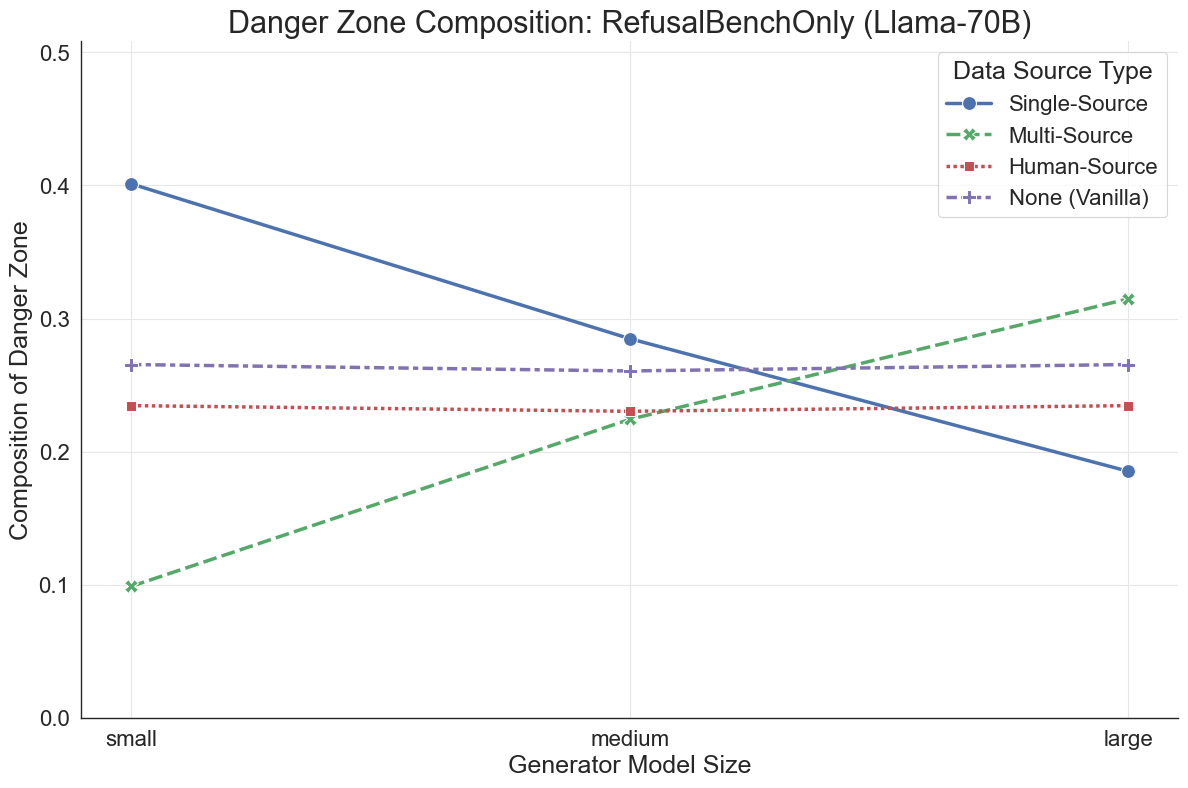


--- Creating and saving Plot 2: RefusalBench+Jailbreak ---


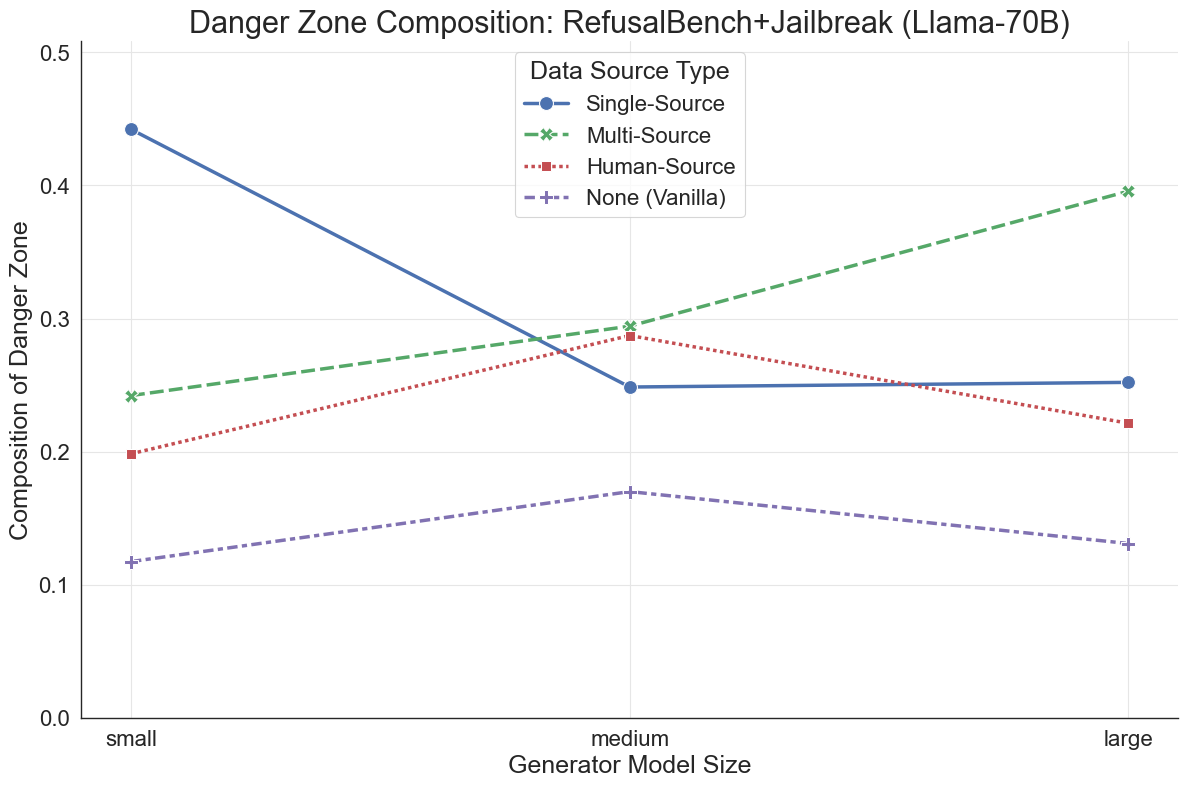

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Loading and Preparation (Same as before) ---
# This assumes `danger_zone_comp_df_70b_by_size` is a loaded pandas DataFrame.
# For example:
# danger_zone_comp_df_70b_by_size = pd.read_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_2/quality_judge/outputs/danger_zone_composition_70b_by_size.csv')
plot_data_line_all = danger_zone_comp_df_70b_by_size.copy()

# Ensure 'Finetune_Size' is categorical for correct plotting order
plot_data_line_all['Finetune_Size'] = pd.Categorical(plot_data_line_all['Finetune_Size'], categories=['small', 'medium', 'large'], ordered=True)

# Define the color palette and line order
custom_palette_line_all = {
    "Single-Source": "#4C72B0",
    "Multi-Source": "#55A868",
    "Human-Source": "#C44E52",
    "None (Vanilla)": "#8172B2"
}
hue_order = ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)']

# --- Calculate a shared Y-axis limit for both plots for fair comparison ---
max_val = max(
    plot_data_line_all['RefusalBench_Jailbreak'].max(),
    plot_data_line_all['RefusalBench_Only'].max()
)
# Add a little padding to the top
y_limit = (0, max_val * 1.15 if max_val > 0 else 1)


# --- PLOT 1: RefusalBenchOnly prompts ---
print("--- Creating and saving Plot 1: RefusalBenchOnly ---")
plt.figure(figsize=(12, 8))

sns.lineplot(
    data=plot_data_line_all,
    x='Finetune_Size',
    y='RefusalBench_Only',
    hue='Model_Type',
    hue_order=hue_order,
    style='Model_Type',
    style_order=hue_order,
    markers=True,
    markersize=10,
    linewidth=2.5,
    palette=custom_palette_line_all
)

# Customize the plot
plt.title('Danger Zone Composition: RefusalBenchOnly (Llama-70B)', fontsize=22)
plt.xlabel('Generator Model Size', fontsize=18)
plt.ylabel('Composition of Danger Zone', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.ylim(y_limit) # Apply the shared y-limit
plt.legend(title='Data Source Type', fontsize=16, title_fontsize=18, loc='best')
plt.tight_layout()

# Save the figure
# Using a descriptive filename for the first plot
#plt.savefig('/Users/maxschaffelder/Desktop/line_plot_dz_refusal_only_70b.png', bbox_inches='tight')
plt.show()


# --- PLOT 2: RefusalBench+Jailbreak prompts ---
print("\n--- Creating and saving Plot 2: RefusalBench+Jailbreak ---")
plt.figure(figsize=(12, 8))

sns.lineplot(
    data=plot_data_line_all,
    x='Finetune_Size',
    y='RefusalBench_Jailbreak',
    hue='Model_Type',
    hue_order=hue_order,
    style='Model_Type',
    style_order=hue_order,
    markers=True,
    markersize=10,
    linewidth=2.5,
    palette=custom_palette_line_all
)

# Customize the plot
plt.title('Danger Zone Composition: RefusalBench+Jailbreak (Llama-70B)', fontsize=22)
plt.xlabel('Generator Model Size', fontsize=18)
plt.ylabel('Composition of Danger Zone', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.ylim(y_limit) # Apply the shared y-limit
plt.legend(title='Data Source Type', fontsize=16, title_fontsize=18, loc='upper center') # Your preferred location
plt.tight_layout()

# Save the figure
# Using a descriptive filename for the second plot
plt.savefig('/Users/maxschaffelder/Desktop/line_plot_dz_jailbreak_70b.png', bbox_inches='tight')
plt.show()
